**ASSIGNMENT 02**

**NAME:** BHOSALE SRUSHTI AMAR

**CLASS:** TY AIDS A

**ROLL NO.:** 23107008

In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

2026-03-05 15:49:47.465651: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-05 15:49:47.474644: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 15:49:47.553590: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 15:49:47.597922: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772705987.640578    4437 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772705987.65

In [4]:
data=fetch_covtype()

X=data.data
y=data.target
y=y-1

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [7]:
model=tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(54,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(7, activation='softmax')])

/home/admin1/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-05 15:49:50.697004: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [9]:
history= model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2)

Epoch 1/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6559 - loss: 0.8347 - val_accuracy: 0.7563 - val_loss: 0.5656
Epoch 2/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7439 - loss: 0.5948 - val_accuracy: 0.7761 - val_loss: 0.5177
Epoch 3/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7604 - loss: 0.5559 - val_accuracy: 0.7934 - val_loss: 0.4827
Epoch 4/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7705 - loss: 0.5312 - val_accuracy: 0.8057 - val_loss: 0.4633
Epoch 5/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7807 - loss: 0.5112 - val_accuracy: 0.8133 - val_loss: 0.4475
Epoch 6/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7866 - loss: 0.5001 - val_accuracy: 0.8174 - val_loss: 0.4324
Epoch 7/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7915 - loss: 0.4876 - val_accuracy: 0.8203 - val_loss: 0.4214
Epoch 8/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7960 - loss: 0.4784 - 

In [17]:
test_loss, test_acc=model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

3632/3632 ━━━━━━━━━━━━━━━━━━━━ 3s 688us/step - accuracy: 0.8532 - loss: 0.3617
Test Accuracy: 0.8518540859222412


In [18]:
y_pred_probs=model.predict(X_test)
y_pred=np.argmax(y_pred_probs, axis=1)+1

3632/3632 ━━━━━━━━━━━━━━━━━━━━ 2s 460us/step


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     42557
           1       0.11      0.08      0.09     56500
           2       0.00      0.04      0.01      7121
           3       0.02      0.34      0.04       526
           4       0.00      0.00      0.00      1995
           5       0.00      0.00      0.00      3489
           6       0.00      0.00      0.00      4015
           7       0.00      0.00      0.00         0

    accuracy                           0.04    116203
   macro avg       0.02      0.06      0.02    116203
weighted avg       0.05      0.04      0.05    116203



/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/admin1/anaconda3/lib/python3.9/si

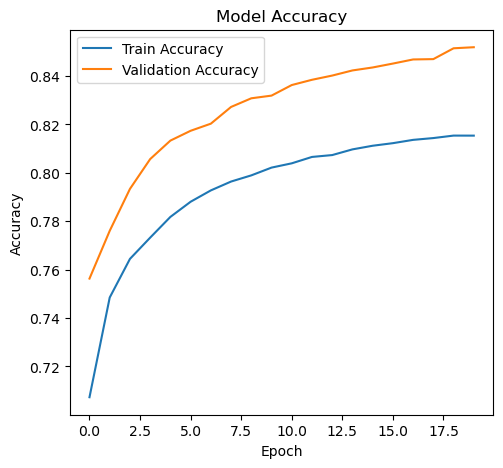

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

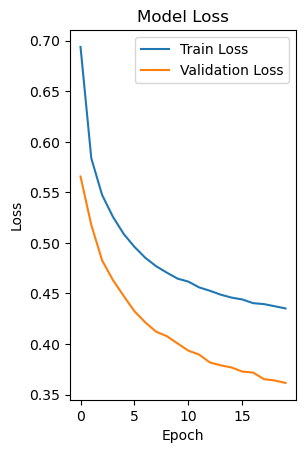

In [26]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()